# U.S. Census Bureau and FRED Case Study: International Trade Analytics

---

## Introduction

This project aims to give an idea of applying **Exploratory Data Analysis Skills from the Data Bootcamp Course** in a real business scenario. We will develop a basic understanding of the **international trade landscape** and understand **how certain economic factors (e.g. exchange rates, energy prices, etc.) influence U.S. international trade**, particularly exports to other nations.

## Data Understanding

This project uses **2 APIs**:

| API | Description |
|---|---|
| `U.S. Census Bureau` | U.S. International Trade information |
| `FRED` | Economic Data Series (e.g. Exchange Rates, Energy Prices, etc.) |


---
## Step 1: Environment Setup & Library Imports

In [ ]:
# Core Libraries
import requests
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

print('Libraries loaded successfully!')

Libraries loaded successfully!


---
## Step 2: Storing API Keys

### 2.1 U.S. Census Bureau API Key

In [ ]:
# Store U.S. Census Bureau API key
census_key = "6a89e1728a6c52727becd167712285f1cf7bc2bb"

### 2.2 FRED API Key

In [ ]:
# Store FRED API key
FRED_key = "2c38bbe4ca6178a77f55b401ac2c4c10"

---
## Step 3: Exploratory Data Analysis — U.S. Census Bureau Data

### 3.1 What does the U.S. International Trade Landscape Look Like?

In [ ]:
# This function gets yearly export data by industry for one year
def get_annual_exports_naics(year, census_key):
    url = "https://api.census.gov/data/timeseries/intltrade/exports/naics"

    # What data to ask for
    params = {
        "get": "NAICS,NAICS_LDESC,ALL_VAL_YR",
        "YEAR": str(year),
        "MONTH": "12",
        "key": census_key
    }
    # Send request
    r = requests.get(url, params=params)
    # Turn response into JSON
    data = r.json()

    # Put data into a dataframe
    df = pd.DataFrame(data[1:], columns=data[0])
    df["ALL_VAL_YR"] = pd.to_numeric(df["ALL_VAL_YR"], errors="coerce") # Convert export values to numbers
    df["year"] = year # Add the year column
    return df

In [ ]:
# This function gets yearly export data by country/region for one year

def get_annual_exports_countries(year, census_key):
    url = "https://api.census.gov/data/timeseries/intltrade/exports/enduse"

    params = {
        "get": "CTY_CODE,CTY_NAME,ALL_VAL_YR",
        "YEAR": str(year),
        "MONTH": "12",
        "key": census_key
    }

    r = requests.get(url, params=params)
    data = r.json()

    df = pd.DataFrame(data[1:], columns=data[0])
    df["ALL_VAL_YR"] = pd.to_numeric(df["ALL_VAL_YR"], errors="coerce")
    df["year"] = year
    return df

In [ ]:
# Years we want to collect data for (around a decade)
years = range(2016, 2026)

# Empty lists to store each year's data
naics_list = []
country_list = []

# Loop through each year and collect the data
for year in years:
    # Get export data by industry for this year
    naics_df_year = get_annual_exports_naics(year, census_key)
    naics_list.append(naics_df_year)

    # Get export data by country for this year
    country_df_year = get_annual_exports_countries(year, census_key)
    country_list.append(country_df_year)


In [ ]:
# Combine all data into one dataframes based on industry and country
naics_df = pd.concat(naics_list, ignore_index=True)
country_df = pd.concat(country_list, ignore_index=True)

In [ ]:
# Clean the industry data: remove rows with missing codes and values
naics_df = naics_df[naics_df["NAICS"] != "-"]
naics_df = naics_df.dropna(subset=["NAICS", "NAICS_LDESC", "ALL_VAL_YR"])

In [ ]:
# Clean country data: remove rows with missing codes,values and broad groups we dont want
country_df = country_df[country_df["CTY_CODE"] != "-"]

remove_groups = ["OPEC", "EUROPEAN UNION", "PACIFIC RIM COUNTRIES", "CAFTA-DR"]
country_df = country_df[~country_df["CTY_NAME"].isin(remove_groups)]

country_df = country_df.dropna(subset=["CTY_NAME", "ALL_VAL_YR"])

In [ ]:
# Group industry data and calculate total exports
industry_summary = (
    naics_df.groupby(["NAICS", "NAICS_LDESC"], as_index=False)
    .agg(total_exports=("ALL_VAL_YR", "sum"))
    .sort_values("total_exports", ascending=False)
)

industry_summary.head(10)

,NAICS,NAICS_LDESC,total_exports
150,31-33,MANUFACTURED GOODS,14553644987868
469,33,"MANUFACTURING, PART 3",9229374888049
293,32,"MANUFACTURING, PART 2",4281574635399
696,336,TRANSPORTATION EQUIPMENT,2712429747530
356,325,CHEMICALS,2387422887827
615,334,COMPUTER AND ELECTRONIC PRODUCTS,2285383234863
552,333,"MACHINERY, EXCEPT ELECTRICAL",1463783292778
99,21,"OIL, GAS, MINERALS AND ORES",1432021599727
727,3364,AEROSPACE PRODUCTS AND PARTS,1285897630439
728,33641,AEROSPACE PRODUCTS AND PARTS,1285897630439


In [ ]:
# Group country data and calculate total exports
country_summary = (
    country_df.groupby("CTY_NAME", as_index=False)
    .agg(total_exports=("ALL_VAL_YR", "sum"))
    .sort_values("total_exports", ascending=False)
)

country_summary.head(10)

,CTY_NAME,total_exports
171,OECD,11975898563099
8,APEC,10798048207238
158,NATO,6717693981405
169,NORTH AMERICA,5910048059472
238,USMCA (NAFTA),5909912998160
13,ASIA,5319706749702
232,TWENTY LATIN AMERICAN REPUBLICS,4386471988092
77,EUROPE,4232533766371
125,LAFTA,3908646517729
43,CANADA,3101077906740


### 3.2 What are the Top Export Industries and Countries for the U.S.?

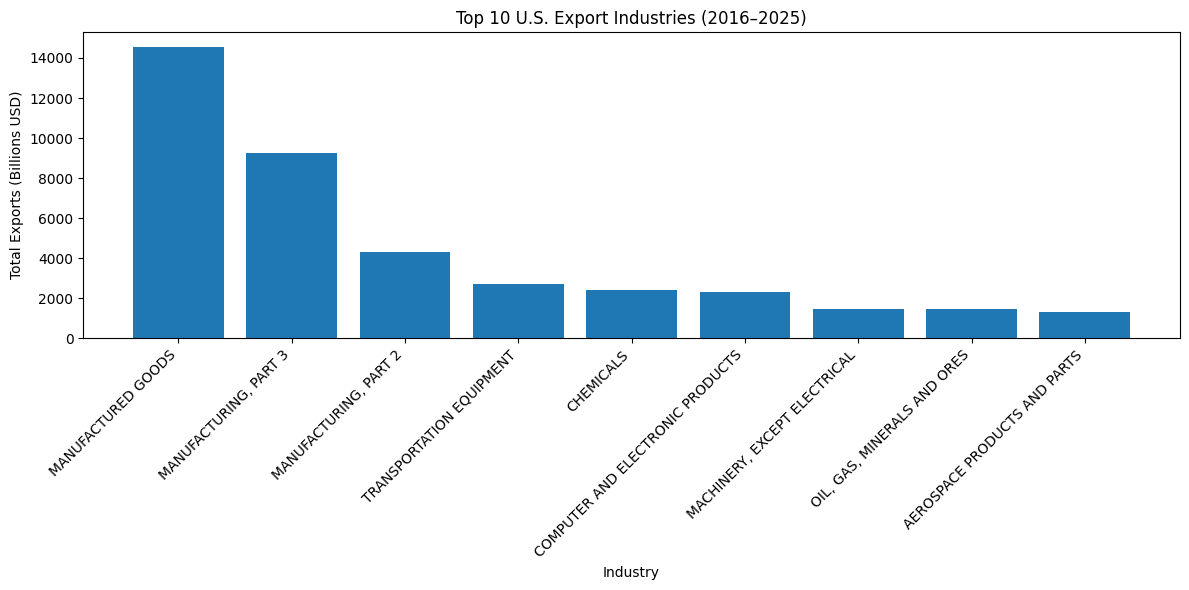

In [ ]:
# Take the top 10 industries
top10_industries = industry_summary.head(10)

# Make a bar chart for the top 10 export industries
plt.figure(figsize=(12, 6))
plt.bar(top10_industries["NAICS_LDESC"], top10_industries["total_exports"] / 1e9)
plt.title("Top 10 U.S. Export Industries (2016–2025)")
plt.xlabel("Industry")
plt.ylabel("Total Exports (Billions USD)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

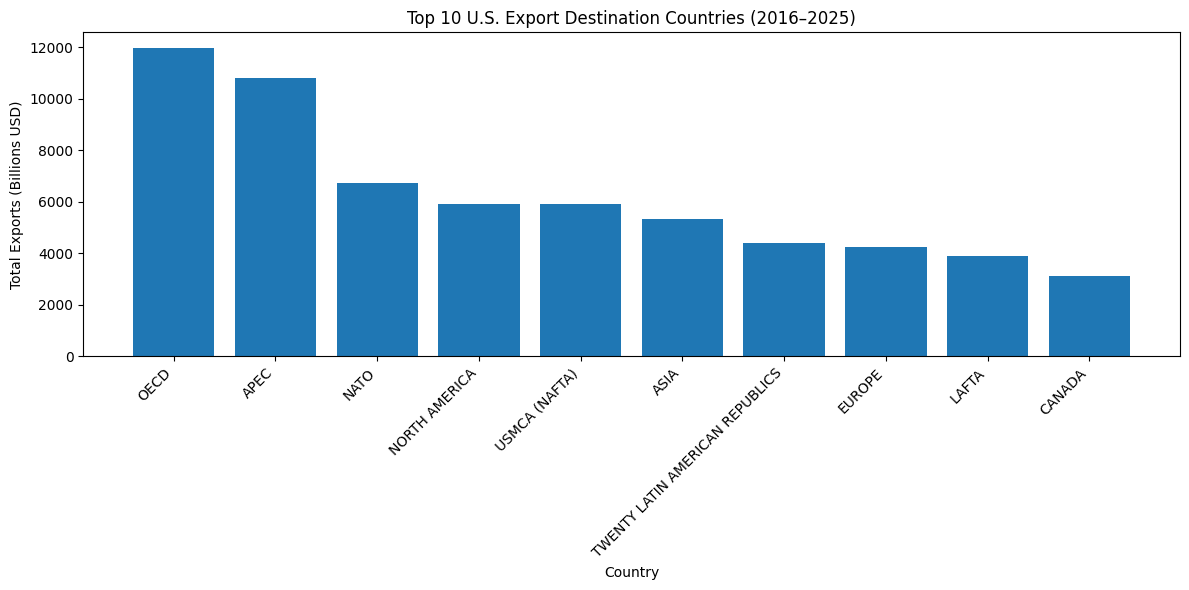

In [ ]:
top10_countries = country_summary.head(10)
# Make a bar chart for the top 10 export destinations
plt.figure(figsize=(12, 6))
plt.bar(top10_countries["CTY_NAME"], top10_countries["total_exports"] / 1e9)
plt.title("Top 10 U.S. Export Destination Countries (2016–2025)")
plt.xlabel("Country")
plt.ylabel("Total Exports (Billions USD)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
# Find the top 5 industries based on total exports across all years
top5_industry_names = (
    naics_df.groupby("NAICS_LDESC", as_index=False)
    .agg(total_exports=("ALL_VAL_YR", "sum"))
    .sort_values("total_exports", ascending=False)
    .head(5)["NAICS_LDESC"]
    .tolist()
)

In [ ]:
# Get yearly export totals for those top 5 industries
yearly_industry = (
    naics_df[naics_df["NAICS_LDESC"].isin(top5_industry_names)]
    .groupby(["year", "NAICS_LDESC"], as_index=False)
    .agg(total_exports=("ALL_VAL_YR", "sum"))
)

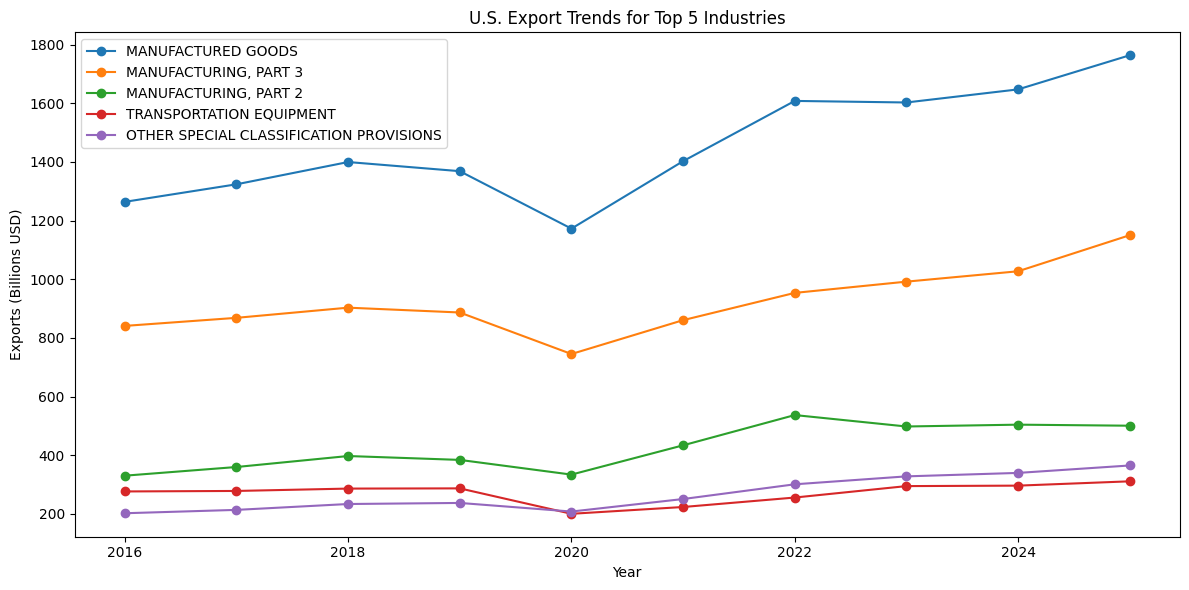

In [ ]:
# Make a line graph for the top 5 industries over time

plt.figure(figsize=(12, 6))

for industry in top5_industry_names:
    temp = yearly_industry[yearly_industry["NAICS_LDESC"] == industry]
    plt.plot(temp["year"], temp["total_exports"] / 1e9, marker="o", label=industry)

plt.title("U.S. Export Trends for Top 5 Industries")
plt.xlabel("Year")
plt.ylabel("Exports (Billions USD)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Find the top 5 export destinations based on total exports across all years
top5_countries = (
    country_df.groupby("CTY_NAME", as_index=False)
    .agg(total_exports=("ALL_VAL_YR", "sum"))
    .sort_values("total_exports", ascending=False)
    .head(5)["CTY_NAME"]
    .tolist()
)

In [ ]:
# Get yearly export totals for those top 5 destinations
yearly_country = (
    country_df[country_df["CTY_NAME"].isin(top5_countries)]
    .groupby(["year", "CTY_NAME"], as_index=False)
    .agg(total_exports=("ALL_VAL_YR", "sum"))
)

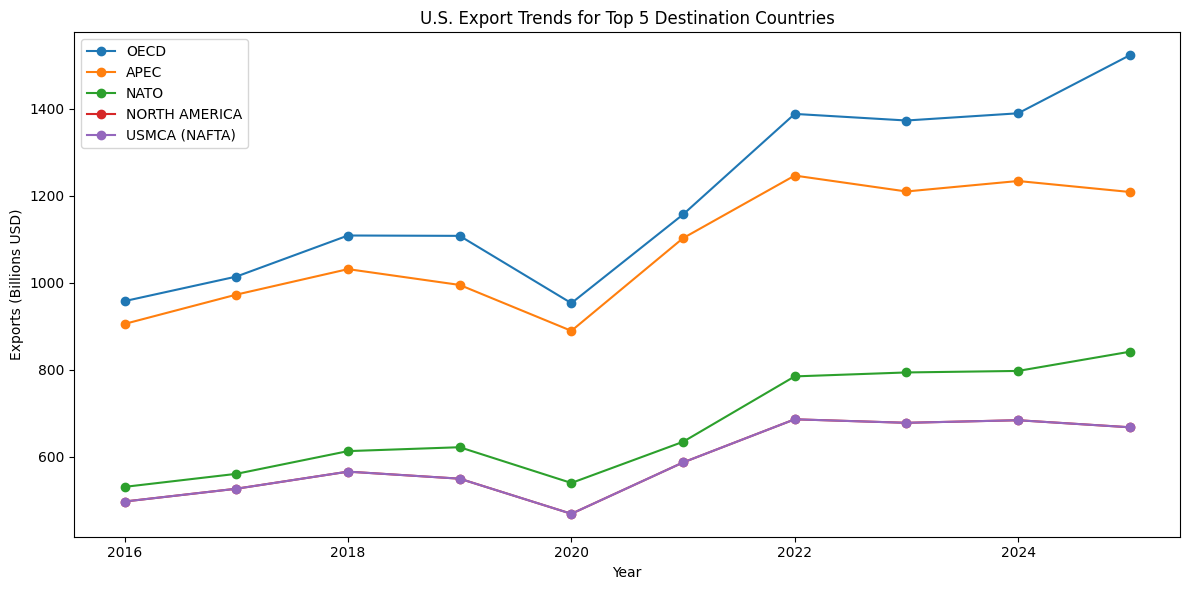

In [ ]:
# Make a line graph for the top 5 destinations over time
plt.figure(figsize=(12, 6))

for country in top5_countries:
    temp = yearly_country[yearly_country["CTY_NAME"] == country]
    plt.plot(temp["year"], temp["total_exports"] / 1e9, marker="o", label=country)

plt.title("U.S. Export Trends for Top 5 Destination Countries")
plt.xlabel("Year")
plt.ylabel("Exports (Billions USD)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Create a new 'period' column.
# .apply() goes through the 'year' column row by row, and the lambda function acts as an IF/ELSE statement
# to label each row as either "Pre-2020" or "2020-2025".
naics_df["period"] = naics_df["year"].apply(lambda x: "Pre-2020" if x < 2020 else "2020-2025")
country_df["period"] = country_df["year"].apply(lambda x: "Pre-2020" if x < 2020 else "2020-2025")

In [ ]:
# Find the average exports for each industry in each period
industry_period = (
    naics_df.groupby(["period", "NAICS_LDESC"], as_index=False)
    .agg(avg_exports=("ALL_VAL_YR", "mean"))
)

In [ ]:
top10_industries_names = industry_summary.head(10)["NAICS_LDESC"].tolist()

# Keep only those top 10 industries
industry_period_top = industry_period[industry_period["NAICS_LDESC"].isin(top10_industries_names)]

### 3.3 What do the Pre vs Post 2020 Export Industries and Countries for the U.S. look like?

In [ ]:
# pivot the table so 'Pre-2020' and '2020-2025' become their own columns
# this makes it way easier to compare the two timeframes side-by-side
industry_period_pivot = industry_period_top.pivot(
    index="NAICS_LDESC",
    columns="period",
    values="avg_exports"
)

industry_period_pivot = industry_period_pivot.loc[top10_industries_names]

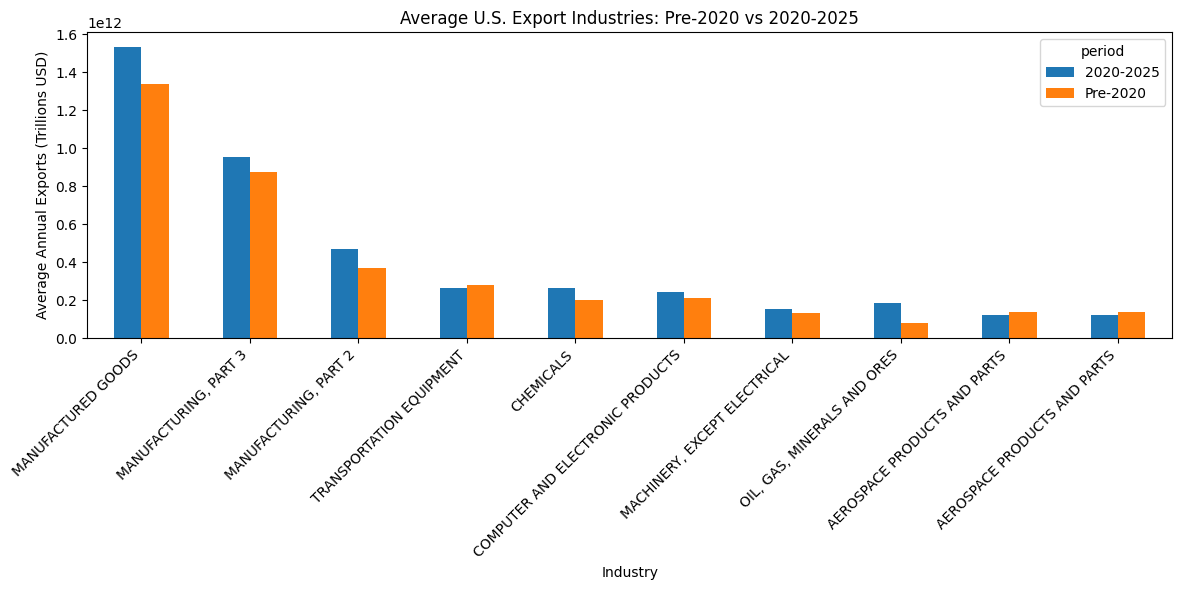

In [ ]:
industry_period_pivot.plot(kind="bar", figsize=(12, 6))
plt.title("Average U.S. Export Industries: Pre-2020 vs 2020-2025")
plt.xlabel("Industry")
plt.ylabel("Average Annual Exports (Trillions USD)")
plt.xticks(rotation=45, ha="right") # rotate the industry names at the bottom 45 degrees so they don't overlap
plt.tight_layout()
plt.show()

In [ ]:
# when you use pivot(), it takes whatever I put as the 'index' (our industry names)
# and permanently sticks them to the side as row labels.
# .reset_index() just pops them back out into a normal column so I can actually use them for the graph.

industry_growth = industry_period.pivot(
    index="NAICS_LDESC",
    columns="period",
    values="avg_exports"
).reset_index()

industry_growth["change"] = industry_growth["2020-2025"] - industry_growth["Pre-2020"]
industry_growth = industry_growth.sort_values("change", ascending=False)

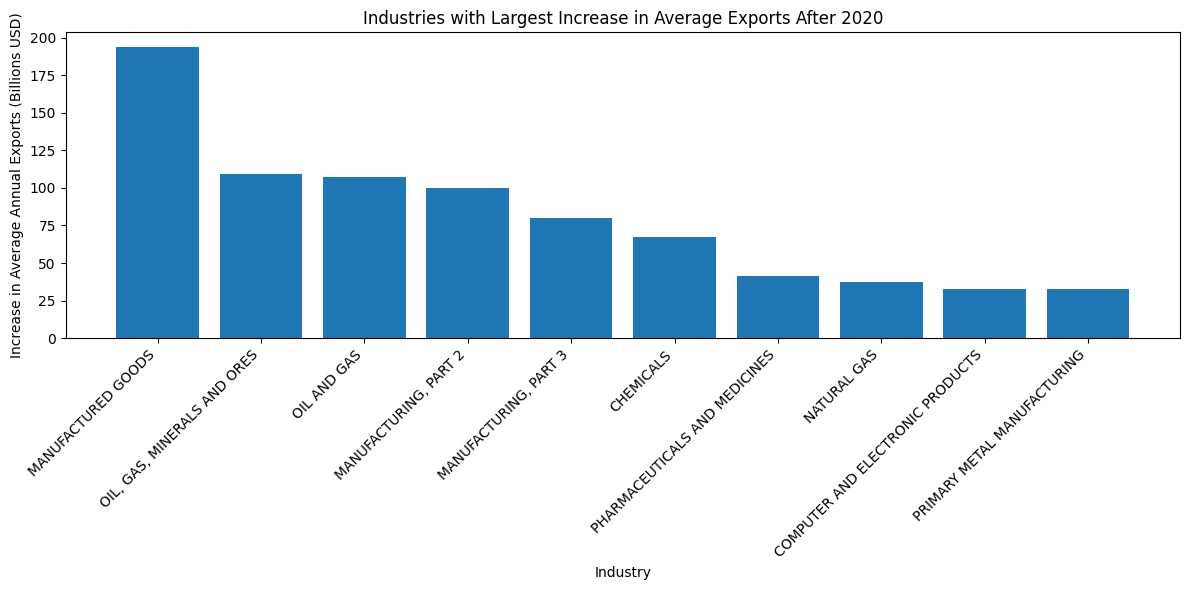

In [ ]:
top_growth_industries = industry_growth.head(10)# Get the top 10 industries with the highest growth

plt.figure(figsize=(12, 6))# Create the chart size
plt.bar(top_growth_industries["NAICS_LDESC"], top_growth_industries["change"] / 1e9)
plt.title("Industries with Largest Increase in Average Exports After 2020")
plt.xlabel("Industry")
plt.ylabel("Increase in Average Annual Exports (Billions USD)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout() # Adjust spacing to avoid overlap
plt.show()

In [ ]:
# Group the data by time period and country
country_period = (
    country_df.groupby(["period", "CTY_NAME"], as_index=False)
    .agg(avg_exports=("ALL_VAL_YR", "mean"))
)

top10_country_names = country_summary.head(10)["CTY_NAME"].tolist()

country_period_top = country_period[country_period["CTY_NAME"].isin(top10_country_names)]

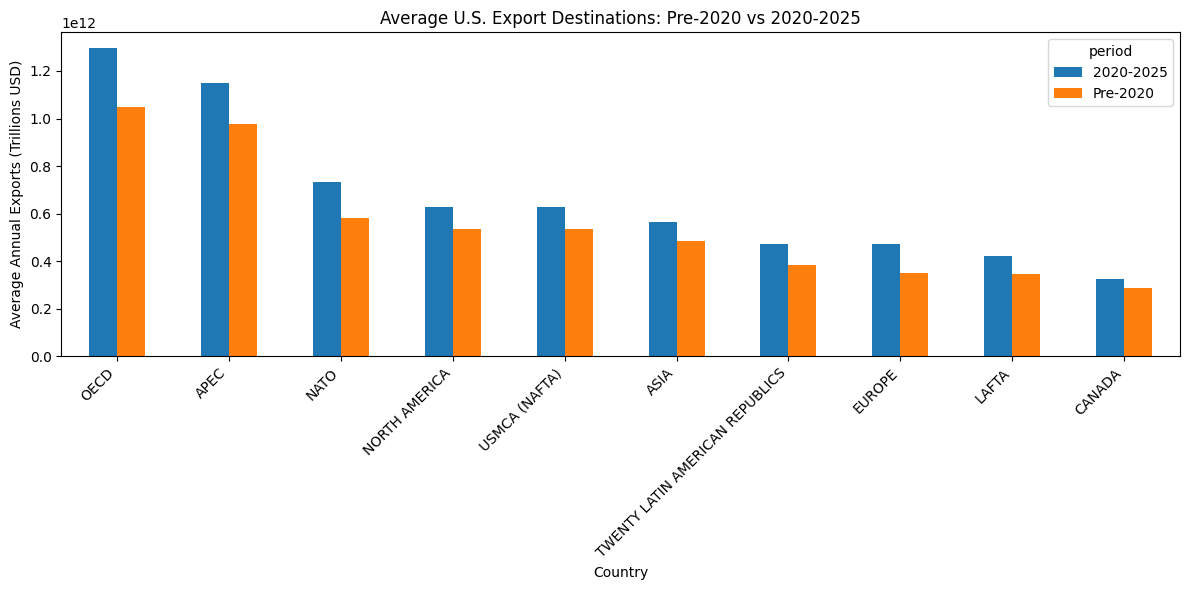

In [ ]:
country_period_pivot = country_period_top.pivot(
    index="CTY_NAME",
    columns="period",
    values="avg_exports"
)# Reshape the data for comparison

country_period_pivot = country_period_pivot.loc[top10_country_names]# Keep the countries in the same order

country_period_pivot.plot(kind="bar", figsize=(12, 6))
plt.title("Average U.S. Export Destinations: Pre-2020 vs 2020-2025")
plt.xlabel("Country")
plt.ylabel("Average Annual Exports (Trillions USD)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
country_growth = country_period.pivot(
    index="CTY_NAME",
    columns="period",
    values="avg_exports"
).reset_index() # Reshape the data to calculate growth

country_growth["change"] = country_growth["2020-2025"] - country_growth["Pre-2020"]
country_growth = country_growth.sort_values("change", ascending=False)

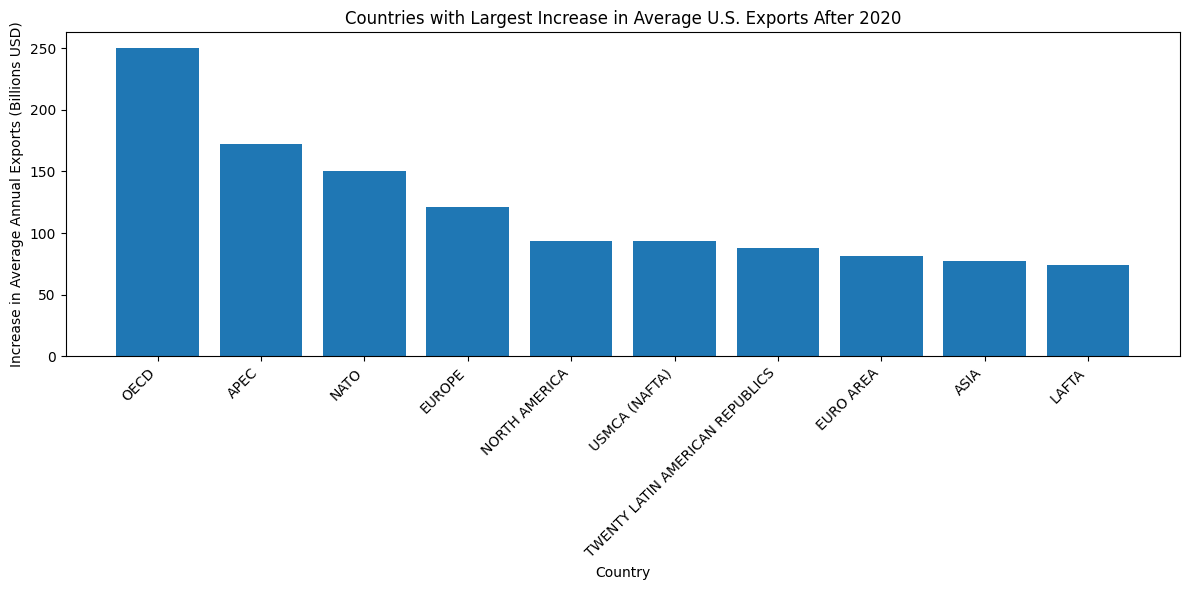

In [ ]:
# Select the top 10 countries with highest growth
top_growth_countries = country_growth.head(10)

plt.figure(figsize=(12, 6))
plt.bar(top_growth_countries["CTY_NAME"], top_growth_countries["change"] / 1e9)
plt.title("Countries with Largest Increase in Average U.S. Exports After 2020")
plt.xlabel("Country")
plt.ylabel("Increase in Average Annual Exports (Billions USD)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 3.4 What are the Top Imports Industies and Countries for the U.S.?

In [ ]:
# This function gets yearly import data by industry for one year
def get_annual_imports_naics(year, census_key):
    url = "https://api.census.gov/data/timeseries/intltrade/imports/naics"

    params = {
        "get": "NAICS,NAICS_LDESC,GEN_VAL_YR",
        "YEAR": str(year),
        "MONTH": "12",
        "key": census_key
    }

    r = requests.get(url, params=params)
    data = r.json()

    df = pd.DataFrame(data[1:], columns=data[0])
    df["GEN_VAL_YR"] = pd.to_numeric(df["GEN_VAL_YR"], errors="coerce")
    df["year"] = year
    return df

In [ ]:
# This function gets yearly import data by country or region for one year
def get_annual_imports_countries(year, census_key):
    url = "https://api.census.gov/data/timeseries/intltrade/imports/enduse"

    params = {
        "get": "CTY_CODE,CTY_NAME,GEN_VAL_YR",
        "YEAR": str(year),
        "MONTH": "12",
        "key": census_key
    }

    r = requests.get(url, params=params)
    data = r.json()

    df = pd.DataFrame(data[1:], columns=data[0])
    df["GEN_VAL_YR"] = pd.to_numeric(df["GEN_VAL_YR"], errors="coerce")
    df["year"] = year
    return df

In [ ]:
# Years we want to collect data for
years = range(2016, 2026)

import_naics_list = []
import_country_list = []

for year in years:
  # Get import data by industry for this year
    import_naics_df_year = get_annual_imports_naics(year, census_key)
    import_naics_list.append(import_naics_df_year)
    # Get import data by country or region for this year
    import_country_df_year = get_annual_imports_countries(year, census_key)
    import_country_list.append(import_country_df_year)

In [ ]:
# Combine all yearly import industry and country data into one dataframe
import_naics_df = pd.concat(import_naics_list, ignore_index=True)
import_country_df = pd.concat(import_country_list, ignore_index=True)

In [ ]:
# Clean the import industry data
import_naics_df = import_naics_df[import_naics_df["NAICS"] != "-"]
import_naics_df = import_naics_df.dropna(subset=["NAICS", "NAICS_LDESC", "GEN_VAL_YR"])

In [ ]:
import_country_df = import_country_df[import_country_df["CTY_CODE"] != "-"] # Remove rows with invalid country codes

remove_groups = ["OPEC", "EUROPEAN UNION", "PACIFIC RIM COUNTRIES", "CAFTA-DR"]# List of country groups to exclude
import_country_df = import_country_df[~import_country_df["CTY_NAME"].isin(remove_groups)]# Remove broad country groups

import_country_df = import_country_df.dropna(subset=["CTY_NAME", "GEN_VAL_YR"])# Drop rows with missing country names or import values


In [ ]:
# Group import data by industry
import_industry_summary = (
    import_naics_df.groupby(["NAICS", "NAICS_LDESC"], as_index=False)
    .agg(total_imports=("GEN_VAL_YR", "sum"))
    .sort_values("total_imports", ascending=False) # Sort industries from highest to lowest imports
)

import_industry_summary.head(15)

,NAICS,NAICS_LDESC,total_imports
154,31-33,MANUFACTURED GOODS,24080532418392
474,33,"MANUFACTURING, PART 3",16242929471716
297,32,"MANUFACTURING, PART 2",5105336357890
621,334,COMPUTER AND ELECTRONIC PRODUCTS,4701426554471
702,336,TRANSPORTATION EQUIPMENT,4091989202168
361,325,CHEMICALS,3058016558371
153,31,"MANUFACTURING, PART1",2732266588786
703,3361,MOTOR VEHICLES,2135694958044
558,333,"MACHINERY, EXCEPT ELECTRICAL",2034433110150
704,33611,"AUTOMOBILES AND LIGHT DUTY MOTOR VEHICLES, INC...",1976690279978


In [ ]:
# Group import data by country
import_country_summary = (
    import_country_df.groupby("CTY_NAME", as_index=False)
    .agg(total_imports=("GEN_VAL_YR", "sum"))
    .sort_values("total_imports", ascending=False)
)

import_country_summary.head(15)

,CTY_NAME,total_imports
8,APEC,18441706358666
171,OECD,16578929070980
13,ASIA,11939910913548
158,NATO,8164504649184
169,NORTH AMERICA,7469093451929
238,USMCA (NAFTA),7468830632689
77,EUROPE,6473117170257
232,TWENTY LATIN AMERICAN REPUBLICS,5184149808314
125,LAFTA,4871883259915
49,CHINA,4602641202392


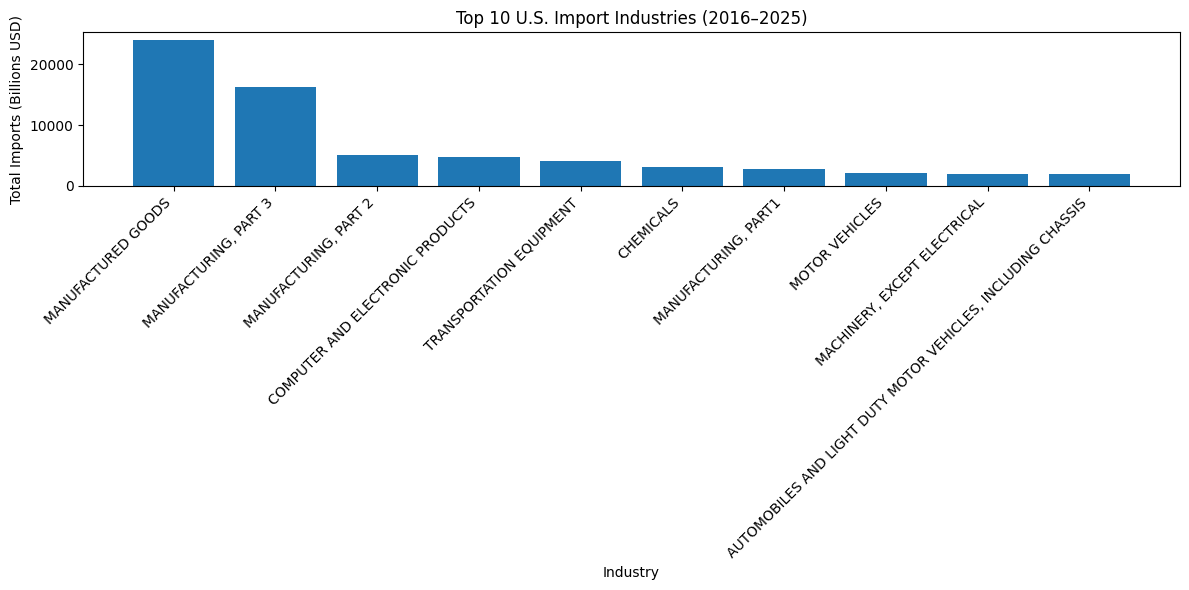

In [ ]:
# Get the top 10 import industries
top10_import_industries = import_industry_summary.head(10)

plt.figure(figsize=(12, 6))
plt.bar(top10_import_industries["NAICS_LDESC"], top10_import_industries["total_imports"] / 1e9)
plt.title("Top 10 U.S. Import Industries (2016–2025)")
plt.xlabel("Industry")
plt.ylabel("Total Imports (Billions USD)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 3.5 What do the Pre vs Post 2020 Imports for Industries and Countries look like for the U.S.?

In [ ]:
# Create a new  column to group the data into two distinct timeframes
# This allows us to compare trade trends before and during/after the 2020 disruptions
import_naics_df["period"] = import_naics_df["year"].apply(lambda x: "Pre-2020" if x < 2020 else "2020-2025")
import_country_df["period"] = import_country_df["year"].apply(lambda x: "Pre-2020" if x < 2020 else "2020-2025")

In [ ]:
# Group import data by period and industry
import_industry_period = (
    import_naics_df.groupby(["period", "NAICS_LDESC"], as_index=False)
    .agg(avg_imports=("GEN_VAL_YR", "mean"))
)

top10_import_industry_names = import_industry_summary.head(10)["NAICS_LDESC"].tolist()

import_industry_period_top = import_industry_period[
    import_industry_period["NAICS_LDESC"].isin(top10_import_industry_names)
]

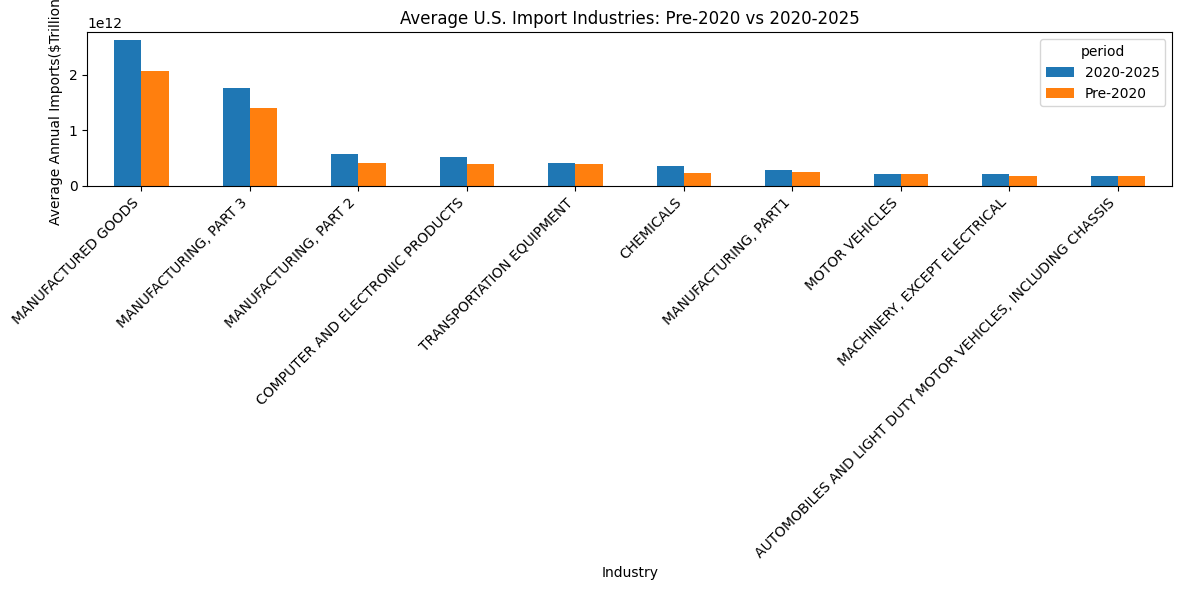

In [ ]:
import_industry_period_pivot = import_industry_period_top.pivot(
    index="NAICS_LDESC",
    columns="period",
    values="avg_imports"
)# Reshape the data for comparison


import_industry_period_pivot = import_industry_period_pivot.loc[top10_import_industry_names] # Keep industries in ranked order

import_industry_period_pivot.plot(kind="bar", figsize=(12, 6)) # Make a bar chart comparing the two periods

plt.title("Average U.S. Import Industries: Pre-2020 vs 2020-2025")
plt.xlabel("Industry")
plt.ylabel("Average Annual Imports($Trillion)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
import_industry_growth = import_industry_period.pivot(
    index="NAICS_LDESC",
    columns="period",
    values="avg_imports"
).reset_index() # Reshape the data to calculate import growth

import_industry_growth["change"] = (
    import_industry_growth["2020-2025"] - import_industry_growth["Pre-2020"]
)# Calculate the change in average imports after 2020

import_industry_growth = import_industry_growth.sort_values("change", ascending=False)# Sort industries by largest increase
import_industry_growth.head(10)

period,NAICS_LDESC,2020-2025,Pre-2020,change
286,MANUFACTURED GOODS,2.636636e+12,2.065179e+12,5.714575e+11
289,"MANUFACTURING, PART 3",1.770668e+12,1.404730e+12,3.659377e+11
288,"MANUFACTURING, PART 2",5.733925e+11,4.162454e+11,1.571471e+11
102,COMPUTER AND ELECTRONIC PRODUCTS,5.211886e+11,3.935738e+11,1.276148e+11
82,CHEMICALS,3.518659e+11,2.367053e+11,1.151606e+11
458,PHARMACEUTICALS AND MEDICINES,2.154362e+11,1.283693e+11,8.706694e+10
490,PRIMARY METAL MANUFACTURING,1.488709e+11,8.861507e+10,6.025581e+10
103,COMPUTER EQUIPMENT,1.529177e+11,9.821294e+10,5.470471e+10
153,"ELECTRICAL EQUIPMENT, APPLIANCES, AND COMPONENT",1.713825e+11,1.167749e+11,5.460754e+10
355,NONFERROUS METAL (EXCEPT ALUMINUM) AND PROCESSING,9.032518e+10,3.857245e+10,5.175273e+10


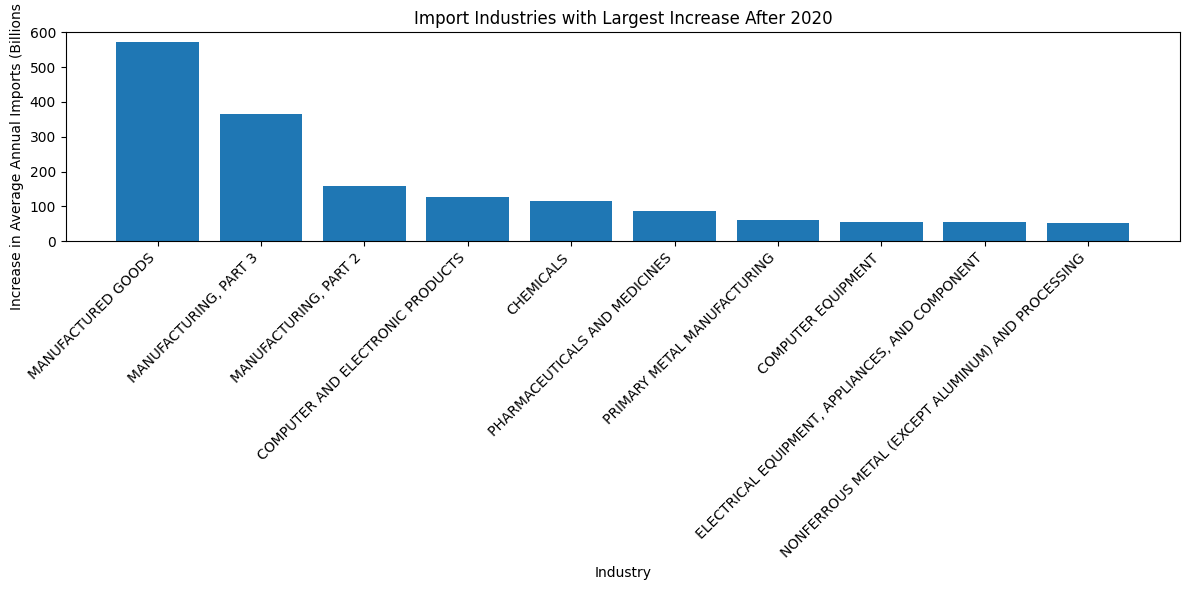

In [ ]:
# Select the top 10 fastest-growing import industries
top_growth_import_industries = import_industry_growth.head(10)

plt.figure(figsize=(12, 6))
plt.bar(top_growth_import_industries["NAICS_LDESC"], top_growth_import_industries["change"] / 1e9)
plt.title("Import Industries with Largest Increase After 2020")
plt.xlabel("Industry")
plt.ylabel("Increase in Average Annual Imports (Billions USD)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
# Group the import data by time period and country
import_country_period = (
    import_country_df.groupby(["period", "CTY_NAME"], as_index=False)
    .agg(avg_imports=("GEN_VAL_YR", "mean"))
)

top10_import_country_names = import_country_summary.head(10)["CTY_NAME"].tolist()

import_country_period_top = import_country_period[
    import_country_period["CTY_NAME"].isin(top10_import_country_names)
]

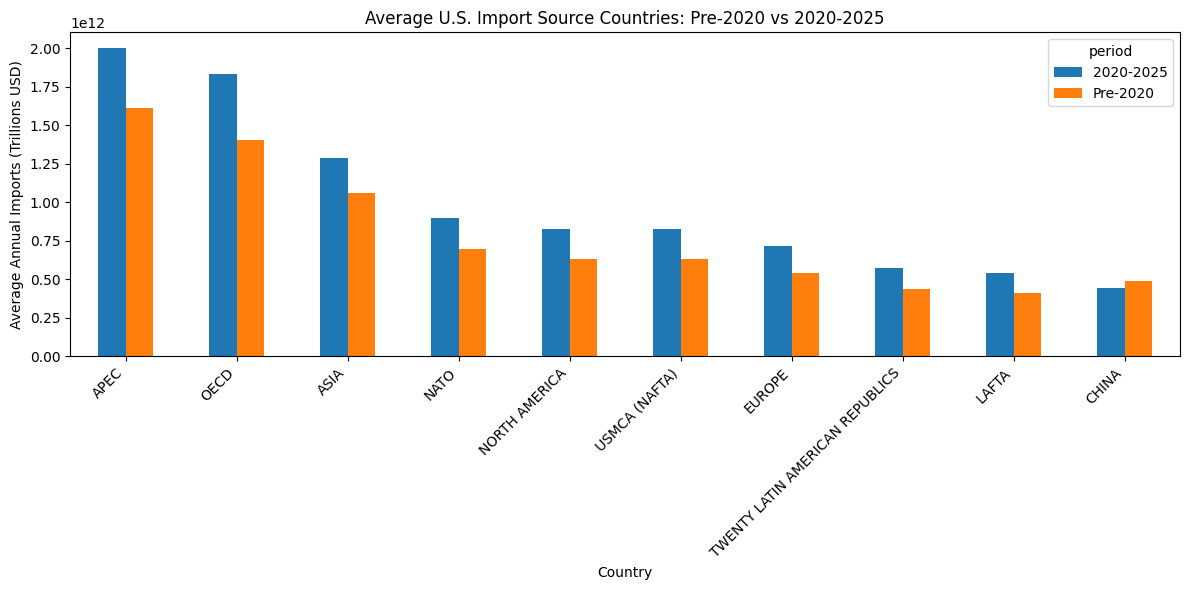

In [ ]:
import_country_period_pivot = import_country_period_top.pivot(
    index="CTY_NAME",
    columns="period",
    values="avg_imports"
)# Reshape the data so each country has one row and each period has its own column


import_country_period_pivot = import_country_period_pivot.loc[top10_import_country_names]
# Create a bar chart to compare imports before and after 2020
import_country_period_pivot.plot(kind="bar", figsize=(12, 6))
plt.title("Average U.S. Import Source Countries: Pre-2020 vs 2020-2025")
plt.xlabel("Country")
plt.ylabel("Average Annual Imports (Trillions USD)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
import_country_growth = import_country_period.pivot(
    index="CTY_NAME",
    columns="period",
    values="avg_imports"
).reset_index()
# Reshape the data so each country has one row and each period has its own column

import_country_growth["change"] = (
    import_country_growth["2020-2025"] - import_country_growth["Pre-2020"]
)

import_country_growth = import_country_growth.sort_values("change", ascending=False)
import_country_growth.head(10)

period,CTY_NAME,2020-2025,Pre-2020,change
171,OECD,1.829679e+12,1.400214e+12,4.294654e+11
8,APEC,2.001651e+12,1.607950e+12,3.937006e+11
13,ASIA,1.285065e+12,1.057380e+12,2.276854e+11
158,NATO,8.948884e+11,6.987935e+11,1.960949e+11
169,NORTH AMERICA,8.248567e+11,6.299883e+11,1.948683e+11
238,USMCA (NAFTA),8.248234e+11,6.299726e+11,1.948508e+11
77,EUROPE,7.179612e+11,5.413375e+11,1.766237e+11
12,ASEAN,3.282609e+11,1.796959e+11,1.485650e+11
232,TWENTY LATIN AMERICAN REPUBLICS,5.740557e+11,4.349540e+11,1.391017e+11
125,LAFTA,5.392460e+11,4.091018e+11,1.301442e+11


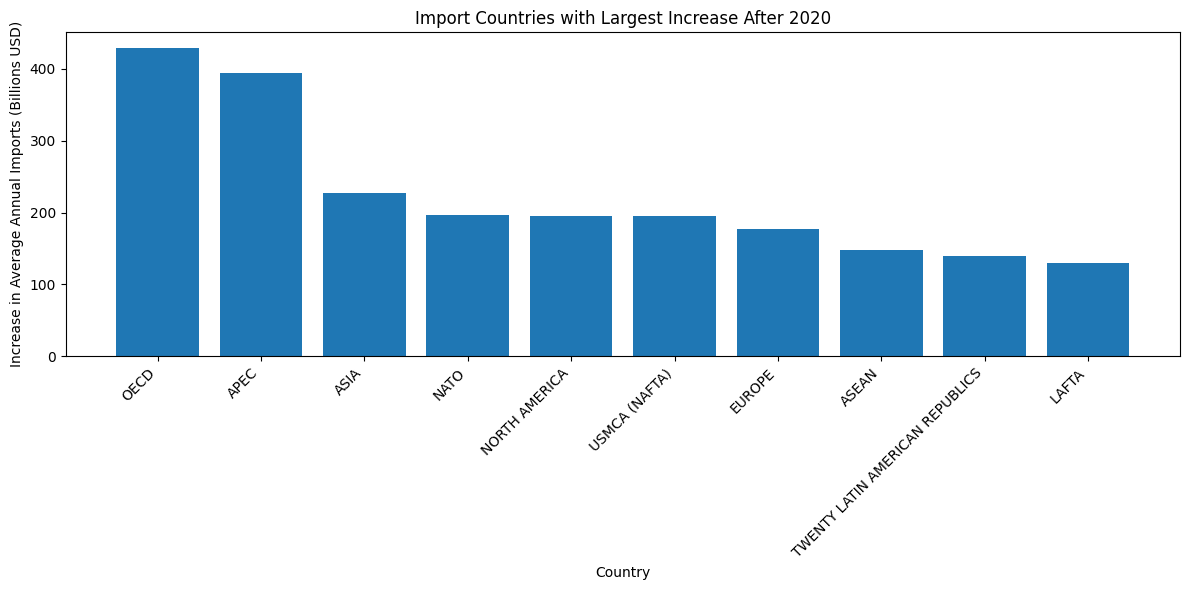

In [ ]:
top_growth_import_countries = import_country_growth.head(10) # Save the top 10 fastest-growing import countries

plt.figure(figsize=(12, 6))
plt.bar(top_growth_import_countries["CTY_NAME"], top_growth_import_countries["change"] / 1e9)
plt.title("Import Countries with Largest Increase After 2020")
plt.xlabel("Country")
plt.ylabel("Increase in Average Annual Imports (Billions USD)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 3.6 Total Imports and Exports Summary

In [ ]:
# total exports by year
export_total_by_year = (
    country_df.groupby("year", as_index=False)
    .agg(total_exports=("ALL_VAL_YR", "sum"))
)

# exports by country and year
export_country_year = (
    country_df.groupby(["year", "CTY_NAME"], as_index=False)
    .agg(country_exports=("ALL_VAL_YR", "sum"))
)

# merge and compute share
export_country_share = export_country_year.merge(export_total_by_year, on="year", how="left")
export_country_share["share"] = export_country_share["country_exports"] / export_country_share["total_exports"]

In [ ]:
top5_export_countries = (
    country_df.groupby("CTY_NAME", as_index=False)
    .agg(total_exports=("ALL_VAL_YR", "sum"))
    .sort_values("total_exports", ascending=False)
    .head(5)["CTY_NAME"]
    .tolist()
)
# Get the names of the top 5 export destination countries
export_country_share_top = export_country_share[
    export_country_share["CTY_NAME"].isin(top5_export_countries)
] # Keep only the top 5 export countries

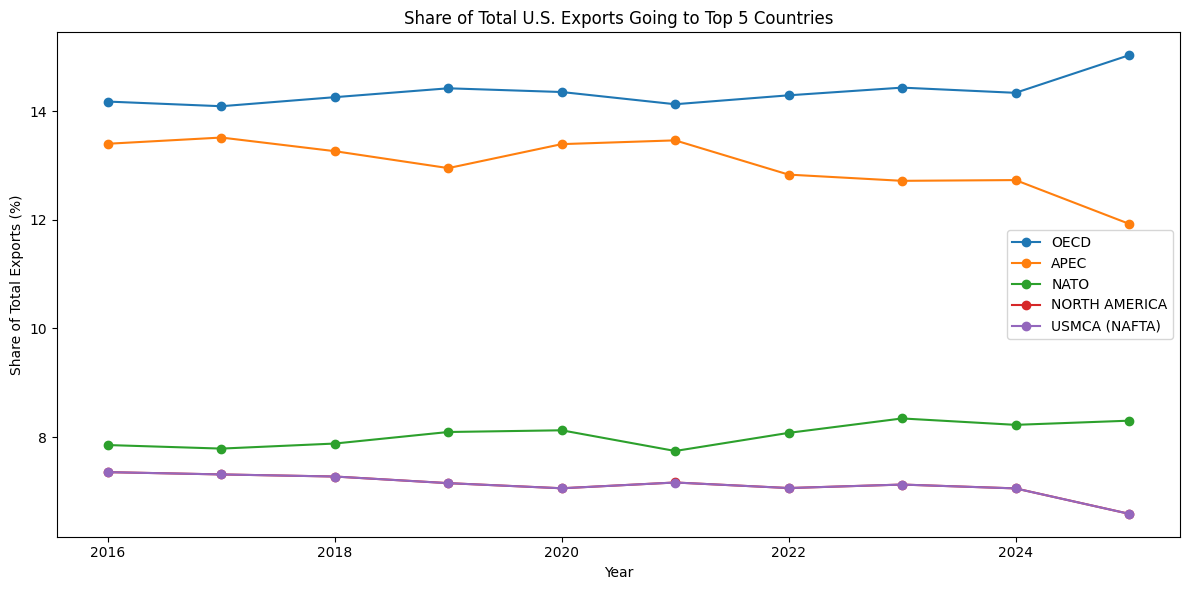

In [ ]:
# Create a new figure for the export share line chart
plt.figure(figsize=(12, 6))

for country in top5_export_countries:
    temp = export_country_share_top[export_country_share_top["CTY_NAME"] == country]# Filter data for one country
    plt.plot(temp["year"], temp["share"] * 100, marker="o", label=country) # Plot that country's export share over time


plt.title("Share of Total U.S. Exports Going to Top 5 Countries")
plt.xlabel("Year")
plt.ylabel("Share of Total Exports (%)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# total imports by year
import_total_by_year = (
    import_country_df.groupby("year", as_index=False)
    .agg(total_imports=("GEN_VAL_YR", "sum"))
)

# imports by country and year
import_country_year = (
    import_country_df.groupby(["year", "CTY_NAME"], as_index=False)
    .agg(country_imports=("GEN_VAL_YR", "sum"))
)

# merge and compute share
import_country_share = import_country_year.merge(import_total_by_year, on="year", how="left")
import_country_share["share"] = import_country_share["country_imports"] / import_country_share["total_imports"]

In [ ]:
# Get the names of the top 5 import source countries
top5_import_countries = (
    import_country_df.groupby("CTY_NAME", as_index=False)
    .agg(total_imports=("GEN_VAL_YR", "sum"))
    .sort_values("total_imports", ascending=False)
    .head(5)["CTY_NAME"]
    .tolist()
)

import_country_share_top = import_country_share[
    import_country_share["CTY_NAME"].isin(top5_import_countries)
]

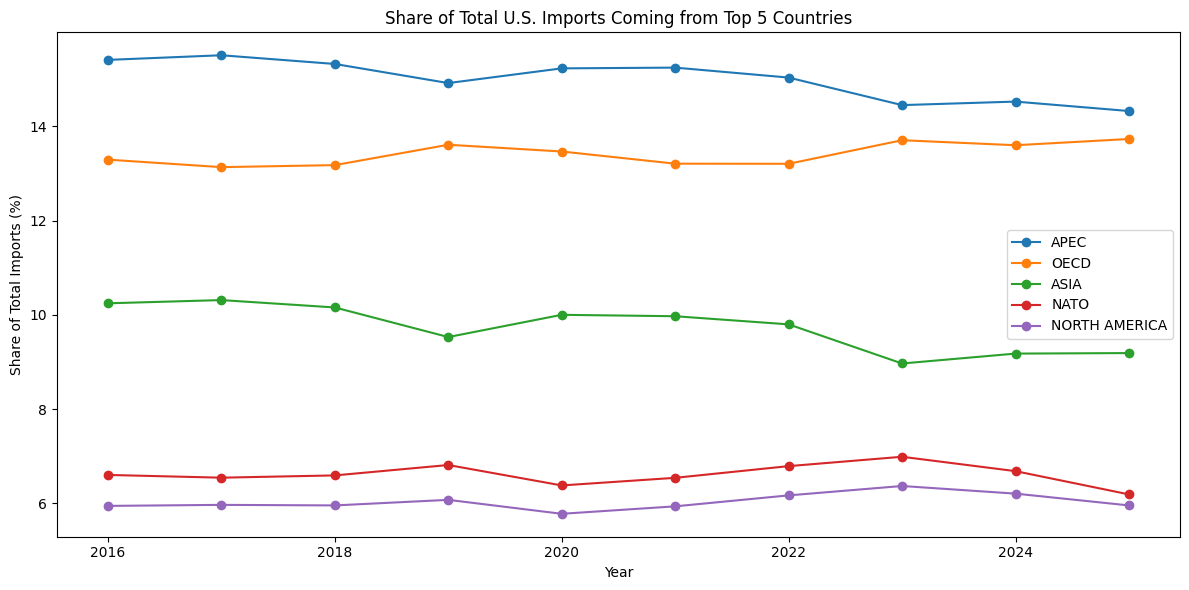

In [ ]:
plt.figure(figsize=(12, 6))# Create a new figure for the import share line chart

for country in top5_import_countries:
    temp = import_country_share_top[import_country_share_top["CTY_NAME"] == country]
    plt.plot(temp["year"], temp["share"] * 100, marker="o", label=country)

plt.title("Share of Total U.S. Imports Coming from Top 5 Countries")
plt.xlabel("Year")
plt.ylabel("Share of Total Imports (%)")
plt.legend()
plt.tight_layout()
plt.show()

---
## Step 4: Exploratory Data Analysis — FRED

### 4.1 Economic Factor Analysis: Do Exchange Rates affect U.S. Foreign Exports?

#### 4.1.1 Loading and Graphing US Exchange Rate Data

In [ ]:
# Retrieves data series from FRED with the corresponding series_id (intended to be exchange rates in this case)
def get_exchange_rates(series_id, api_key):
  url = "https://api.stlouisfed.org/fred/series/observations"

  params = {
    "series_id": series_id,
    "api_key": api_key,
    "file_type": "json"
  }

  response = requests.get(url, params=params)
  data = response.json()
  return data

In [ ]:
### Retrieving observations for USD/JPY data series from FRED and creating DataFrame for USD/JPY Exchange Rate

# Series_id for the USD/JPY data series from FRED
Yen_to_USD = "DEXJPUS"

# Retrieve Yen to USD Exchange Rate and creates a dataframe with the observations
Yen_to_USD_df = pd.DataFrame(get_exchange_rates(Yen_to_USD, FRED_key)["observations"])
Yen_to_USD_df["date"] = pd.to_datetime(Yen_to_USD_df["date"])
Yen_to_USD_df["value"] = pd.to_numeric(Yen_to_USD_df["value"], errors="coerce")

# Renames Columns
Yen_to_USD_df.rename(inplace = True, columns = {"value" : "USD/JPY"})

Yen_to_USD_df.head()

,realtime_start,realtime_end,date,USD/JPY
0,2026-03-23,2026-03-23,1971-01-04,357.73
1,2026-03-23,2026-03-23,1971-01-05,357.81
2,2026-03-23,2026-03-23,1971-01-06,357.86
3,2026-03-23,2026-03-23,1971-01-07,357.87
4,2026-03-23,2026-03-23,1971-01-08,357.82


In [ ]:
### Retrieving observations for EUR/USD data series from FRED and creating DataFrame for USD/EUR Exchange Rate

# Series_id for the EUR/USD data series from FRED
Euro_to_USD = "DEXUSEU"

# Retreive Euro to USD Exchange Rate
Euro_to_USD_df = pd.DataFrame(get_exchange_rates(Euro_to_USD, FRED_key)["observations"])
Euro_to_USD_df["date"] = pd.to_datetime(Euro_to_USD_df["date"])
Euro_to_USD_df["value"] = pd.to_numeric(Euro_to_USD_df["value"], errors="coerce")

# Invert Euro to USD
Euro_to_USD_df["value"] = 1 / Euro_to_USD_df["value"]

# Rename Columns
Euro_to_USD_df.rename(inplace = True, columns = {"value" : "USD/EUR"})

Euro_to_USD_df.head()

,realtime_start,realtime_end,date,USD/EUR
0,2026-03-23,2026-03-23,1999-01-04,0.846597
1,2026-03-23,2026-03-23,1999-01-05,0.850340
2,2026-03-23,2026-03-23,1999-01-06,0.859402
3,2026-03-23,2026-03-23,1999-01-07,0.856751
4,2026-03-23,2026-03-23,1999-01-08,0.865501


In [ ]:
### Retrieving observations for USD/CH data series from FRED and creating DataFrame for USD/CH Exchange Rate

# Series_id for the USD/CH data series from FRED
Yuan_to_USD = "DEXCHUS"

# Retrieve Yuan to USD Exchange Rate
Yuan_to_USD_df = pd.DataFrame(get_exchange_rates(Yuan_to_USD, FRED_key)["observations"])
Yuan_to_USD_df["date"] = pd.to_datetime(Yuan_to_USD_df["date"])
Yuan_to_USD_df["value"] = pd.to_numeric(Yuan_to_USD_df["value"], errors="coerce")

# Rename Columns
Yuan_to_USD_df.rename(inplace = True, columns = {"value" : "USD/CH"})

Yuan_to_USD_df.head()

,realtime_start,realtime_end,date,USD/CH
0,2026-03-24,2026-03-24,1981-01-02,1.5341
1,2026-03-24,2026-03-24,1981-01-05,1.5418
2,2026-03-24,2026-03-24,1981-01-06,1.5264
3,2026-03-24,2026-03-24,1981-01-07,1.5264
4,2026-03-24,2026-03-24,1981-01-08,1.5264


In [ ]:
### Merging exchange dataframes and indexing against date, specifically observations from 2010 to present

list_of_relevant_dfs = [Yuan_to_USD_df, Yen_to_USD_df, Euro_to_USD_df]
res = []

# Create list of exchange dataframes with observations from 2010 to present
for df in list_of_relevant_dfs:
  df = df[df["date"] >= "2010-01-01"]
  df = df.drop('realtime_start', axis=1)
  df = df.drop('realtime_end', axis=1)
  res.append(df)

# Merge all exchange rate dataframes and drop missing values
merged_df = res[0].merge(res[1], on = "date")
merged_df = merged_df.merge(res[2], on = "date")
merged_df = merged_df.dropna()

# Index the merged dataframe by date
merged_df['date'] = pd.to_datetime(merged_df['date'])
merged_df = merged_df.set_index('date')

merged_df.head()

,USD/CH,USD/JPY,USD/EUR
date,,,
2010-01-04,6.8273,92.55,0.693529
2010-01-05,6.8258,91.48,0.694348
2010-01-06,6.8272,92.53,0.694252
2010-01-07,6.8280,93.31,0.698617
2010-01-08,6.8274,92.70,0.696524


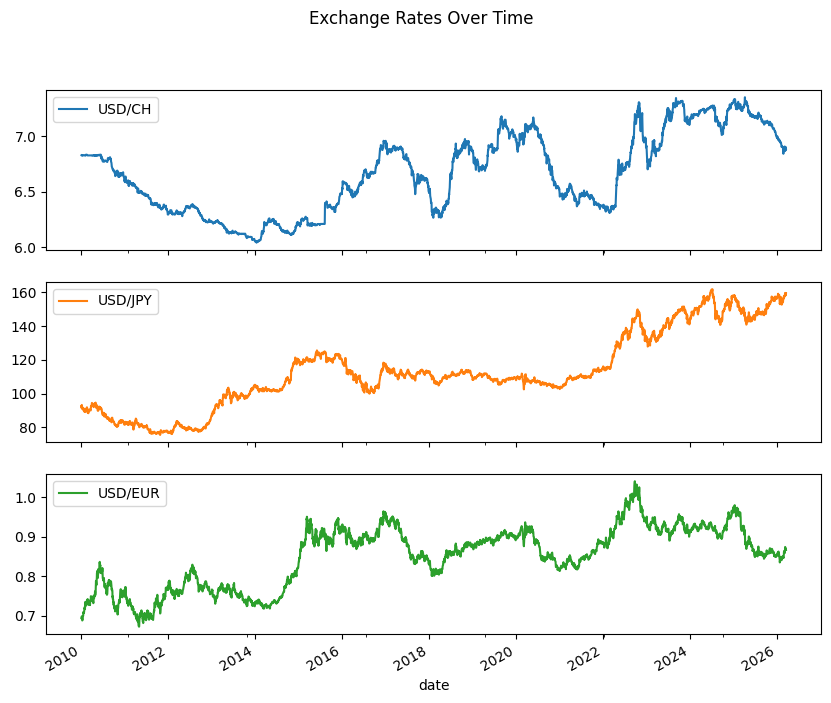

In [ ]:
### Testing to see if graphing USD exchange rates against the Yuan, Yen, and Euro works properly

merged_df.plot(
    subplots=True,
    figsize=(10,8),
    layout=(-1,1),  # one column, multiple rows
    sharex=True,
    legend=True
)

plt.suptitle("Exchange Rates Over Time")
plt.show()

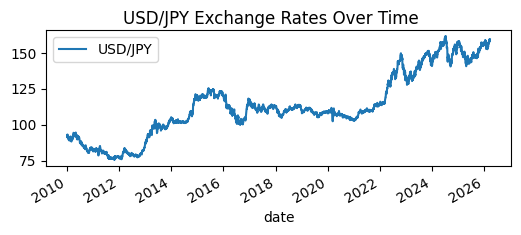

In [ ]:
### Testing to see if individual graph of USD exchange rates against Yen works properly

merged_df['USD/JPY'].plot(
    subplots=False,
    figsize=(6,2),
    layout=(-1,1),  # one column, multiple rows
    sharex=True,
    legend=True
)
plt.suptitle("USD/JPY Exchange Rates Over Time")
plt.show()

#### 4.1.2 Loading and Graphing Exports Data

In [ ]:
### Retrieving US export data from some countries that use one of the currencies in the exchange rates of interest

base_url = "https://api.census.gov/data/timeseries/intltrade/exports/hs"

# Countries of Interest for Analysis
countries = {
    "China": "5700",
    "Japan": "5880",
    "France": "4279"
}

dfs = []

# Retrieve export data from each country and add to the list dataframes-to-be-merged
for name, code in countries.items():
    url = f"{base_url}?get=ALL_VAL_MO,CTY_NAME&CTY_CODE={code}&time=from+2000"

    df = pd.read_json(url)
    df.columns = df.iloc[0]
    df = df[1:]

    df["date"] = pd.to_datetime(df["time"])
    df[name] = pd.to_numeric(df["ALL_VAL_MO"])

    dfs.append(df[["date", name]])

# Merged export data from all countries of interest into one dataframe
merged_exports = dfs[0]
for df in dfs[1:]:
    merged_exports = merged_exports.merge(df, on="date")

# Sort export data
merged_exports = merged_exports.sort_values("date")

# Index the merged dataframe by date
merged_exports['date'] = pd.to_datetime(merged_exports['date'])
merged_exports = merged_exports.set_index('date')

merged_exports.head()

,China,Japan,France
date,,,
2010-01-01,6898358856,4840292937,2011082560
2010-02-01,6840227481,4625432423,2034749676
2010-03-01,7400774615,5073197176,2360525058
2010-04-01,6600725426,4493850674,2232191300
2010-05-01,6755285795,5193089945,2242324120


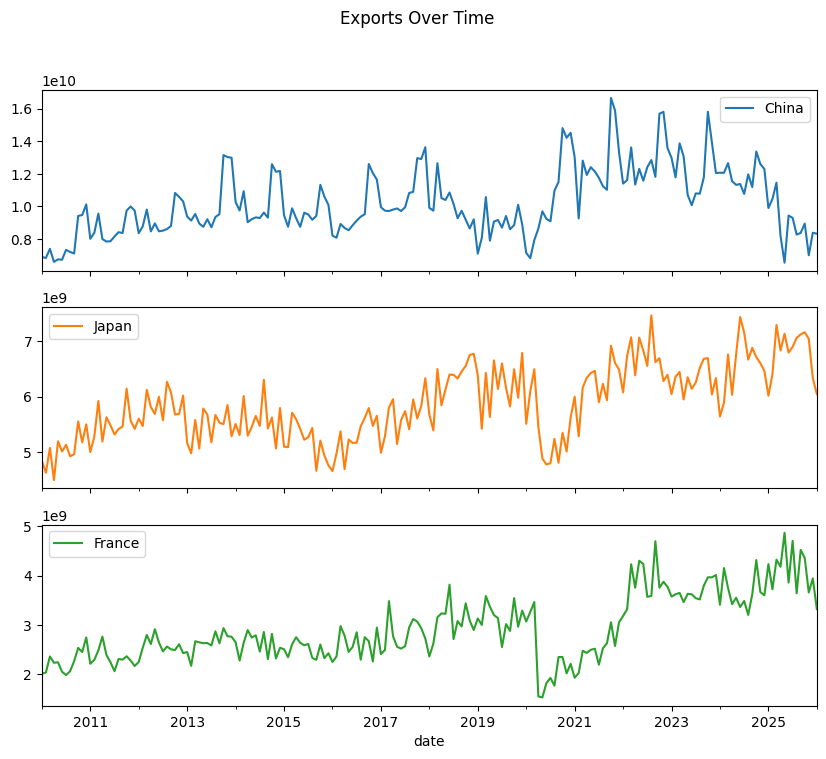

In [ ]:
### Testing to if graphing US exports over time to China, Japan, and France works properly

merged_exports.plot(
    subplots=True,
    figsize=(10,8),
    layout=(-1,1),  # one column, multiple rows
    sharex=True,
    legend=True
)

plt.suptitle("Exports Over Time")
plt.show()

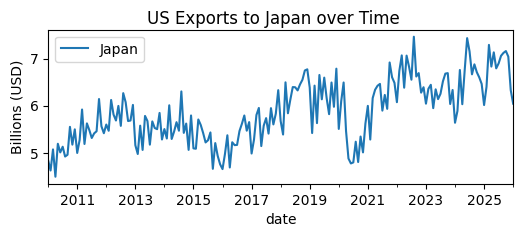

In [ ]:
### Modifying individual graph of USD exchange rates against Yen with appropriate title and axis titles

(merged_exports['Japan'] / 1e9).plot(
    subplots=False,
    figsize=(6,2),
    layout=(-1,1),
    sharex=True,
    legend=True
)
plt.suptitle("US Exports to Japan over Time")
plt.ylabel("Billions (USD)")
plt.show()

#### 4.1.3 Finalizing Combined Exchange Rate and Export Graphs for Write-Up Formatting

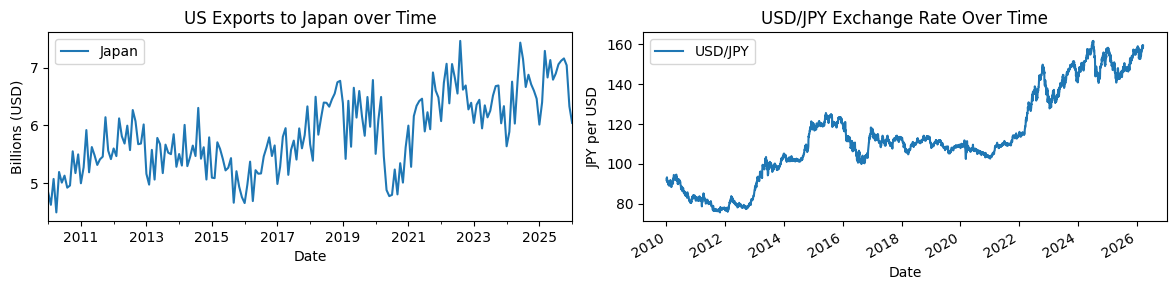

In [ ]:
# US and Japan
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3))

# Exports chart
(merged_exports['Japan'] / 1000000000).plot(ax=ax1, legend=True)
ax1.set_title("US Exports to Japan over Time")
ax1.set_ylabel("Billions (USD)")
ax1.set_xlabel("Date")

# Exchange rate chart
merged_df['USD/JPY'].plot(ax=ax2, legend=True)
ax2.set_title("USD/JPY Exchange Rate Over Time")
ax2.set_ylabel("JPY per USD")
ax2.set_xlabel("Date")

plt.tight_layout()
plt.show()

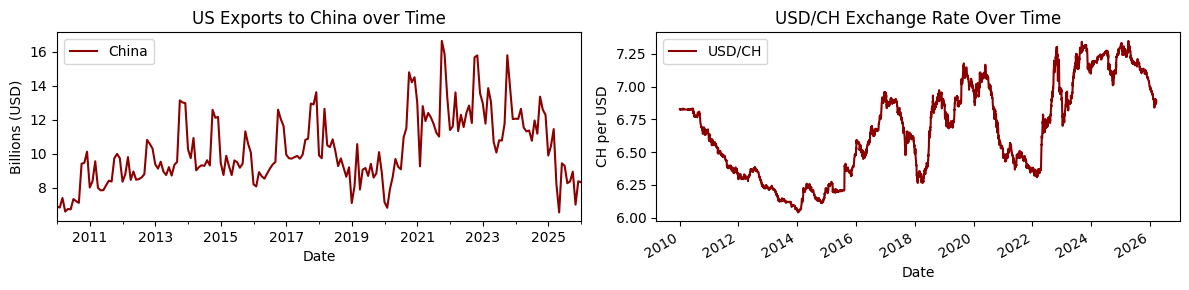

In [ ]:
# US and China
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3))

# Exports chart
(merged_exports['China'] / 1000000000).plot(ax=ax1, legend=True, color= 'darkred')
ax1.set_title("US Exports to China over Time")
ax1.set_ylabel("Billions (USD)")
ax1.set_xlabel("Date")

# Exchange rate chart
merged_df['USD/CH'].plot(ax=ax2, legend=True, color = 'darkred')
ax2.set_title("USD/CH Exchange Rate Over Time")
ax2.set_ylabel("CH per USD")
ax2.set_xlabel("Date")

plt.tight_layout()
plt.show()

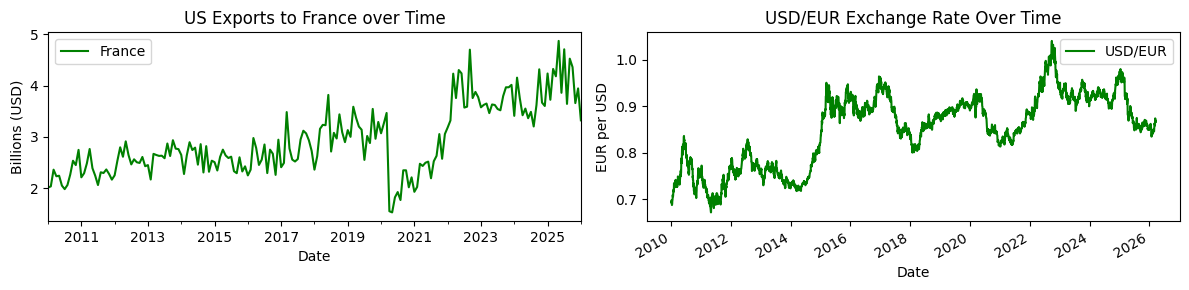

In [ ]:
# US and France
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3))

# Exports chart
(merged_exports['France'] / 1000000000).plot(ax=ax1, legend=True, color= 'green')
ax1.set_title("US Exports to France over Time")
ax1.set_ylabel("Billions (USD)")
ax1.set_xlabel("Date")

# Exchange rate chart
merged_df['USD/EUR'].plot(ax=ax2, legend=True, color = 'green')
ax2.set_title("USD/EUR Exchange Rate Over Time")
ax2.set_ylabel("EUR per USD")
ax2.set_xlabel("Date")

plt.tight_layout()
plt.show()

### 4.2 Economic Factor Analysis: Do Changes in Energy Price affect U.S. Foreign Exports?

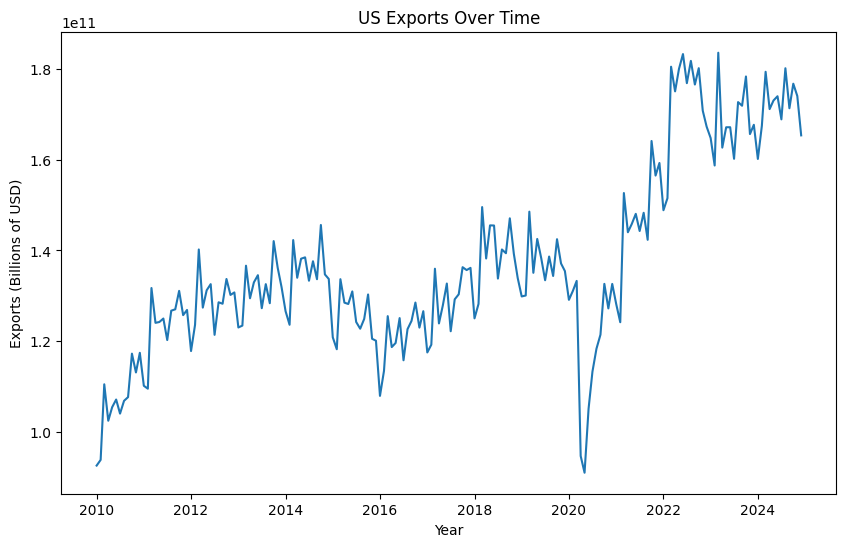

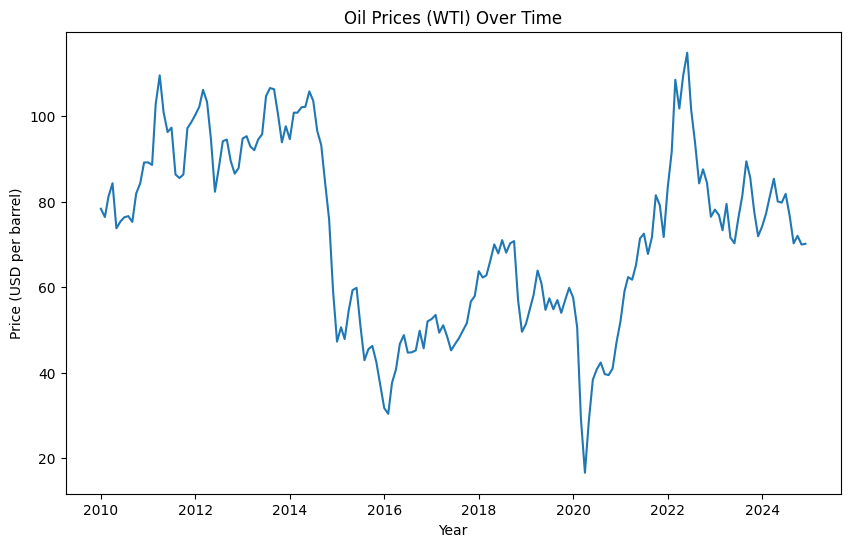

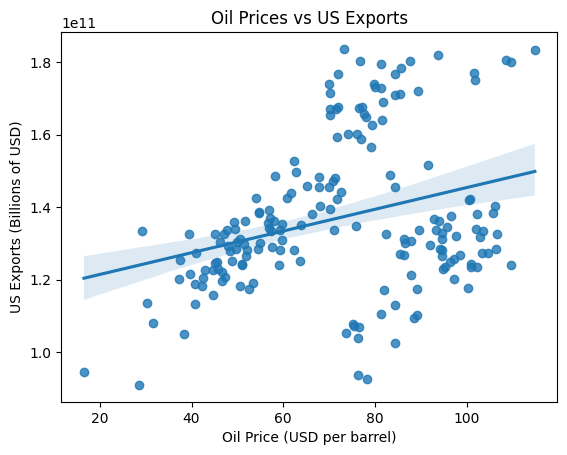

Correlation (Oil vs Exports): 0.30675817008205797


In [ ]:
# FRED helper function
def get_fred_data(series_id, FRED_KEY):
    url = f"https://api.stlouisfed.org/fred/series/observations?series_id={series_id}&api_key={FRED_key}&file_type=json"
    r = requests.get(url)
    result = r.json()
    df = pd.DataFrame(result['observations'])[['date','value']]
    df['value'] = pd.to_numeric(df['value'], errors='coerce')
    df['date'] = pd.to_datetime(df['date'])
    return df.dropna().rename(columns={'value':series_id})

# Download FRED data for oil prices
oil = get_fred_data("DCOILWTICO", FRED_key)
oil = oil.set_index("date").resample("ME").mean().reset_index()

# Download Census exports
url = "https://api.census.gov/data/timeseries/intltrade/exports/hs"
params = {"get":"ALL_VAL_MO","time":"from 2010-01 to 2024-12","key":census_key}
r = requests.get(url, params=params)
data = r.json()
exports = pd.DataFrame(data[1:], columns=data[0])
exports["ALL_VAL_MO"] = pd.to_numeric(exports["ALL_VAL_MO"])
exports["time"] = pd.to_datetime(exports["time"])
exports = exports.groupby("time")["ALL_VAL_MO"].sum().reset_index()
exports = exports.rename(columns={"time":"date","ALL_VAL_MO":"exports"})

# Merge on month
exports["month"] = exports["date"].dt.to_period("M")
oil["month"] = oil["date"].dt.to_period("M")
oil = oil.drop(columns=["date"])
df_oil = exports.merge(oil, on="month", how="inner")
df_oil["date"] = df_oil["month"].dt.to_timestamp()

# Plots
plt.figure(figsize=(10,6))
plt.plot(df_oil["date"], df_oil["exports"])
plt.title("US Exports Over Time")
plt.xlabel("Year")
plt.ylabel("Exports (Billions of USD)")
plt.show()

plt.figure(figsize=(10,6))
plt.plot(df_oil["date"], df_oil["DCOILWTICO"])
plt.title("Oil Prices (WTI) Over Time")
plt.xlabel("Year")
plt.ylabel("Price (USD per barrel)")
plt.show()

sns.regplot(x=df_oil["DCOILWTICO"], y=df_oil["exports"])
plt.title("Oil Prices vs US Exports")
plt.xlabel("Oil Price (USD per barrel)")
plt.ylabel("US Exports (Billions of USD)")
plt.show()

print("Correlation (Oil vs Exports):", df_oil["exports"].corr(df_oil["DCOILWTICO"]))

### 4.3 Economic Factor Analysis: Do Changes in Interest Rate affect U.S. Foreign Exports?

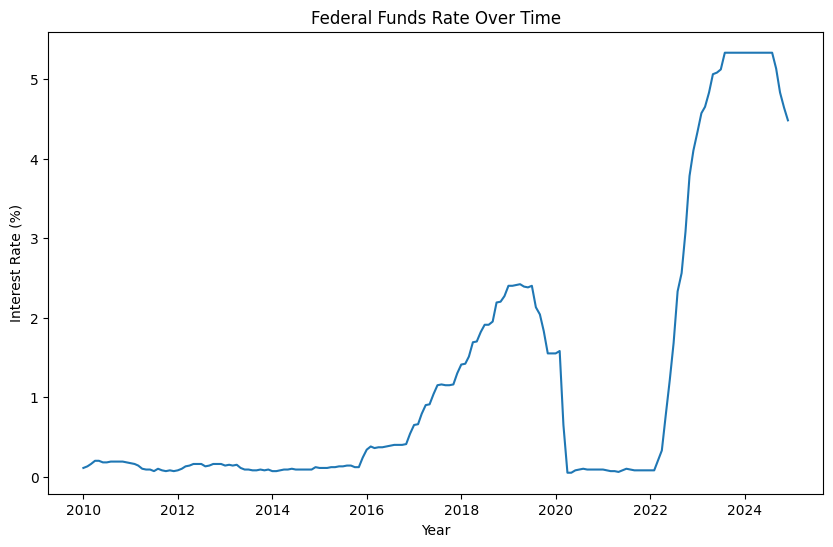

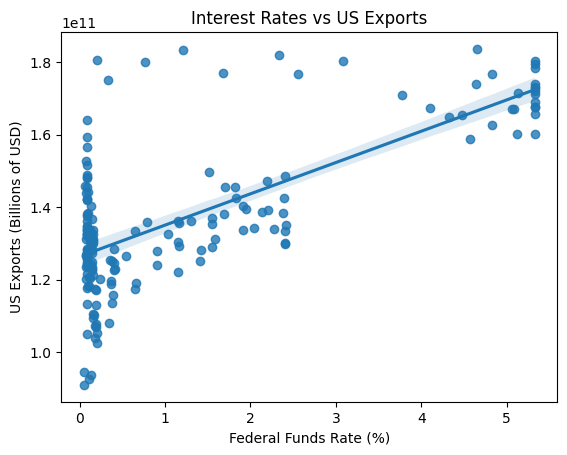

Correlation (Interest Rates vs Exports): 0.7113950810472565


In [ ]:
# Download FRED data for interest rates
rates = get_fred_data("FEDFUNDS", FRED_key)
rates = rates.set_index("date").resample("ME").mean().reset_index()
rates["month"] = rates["date"].dt.to_period("M")
rates = rates.drop(columns=["date"])

df_rates = exports.merge(rates, on="month", how="inner")
df_rates["date"] = df_rates["month"].dt.to_timestamp()

# Plots
plt.figure(figsize=(10,6))
plt.plot(df_rates["date"], df_rates["FEDFUNDS"])
plt.title("Federal Funds Rate Over Time")
plt.xlabel("Year")
plt.ylabel("Interest Rate (%)")
plt.show()

sns.regplot(x=df_rates["FEDFUNDS"], y=df_rates["exports"])
plt.title("Interest Rates vs US Exports")
plt.xlabel("Federal Funds Rate (%)")
plt.ylabel("US Exports (Billions of USD)")
plt.show()

print("Correlation (Interest Rates vs Exports):", df_rates["exports"].corr(df_rates["FEDFUNDS"]))